<a href="https://colab.research.google.com/github/Katab-sawan/Dissertation/blob/Inter-Stock-Analysis/Inter_StockAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
from datetime import datetime

tech_list = ['TSLA', 'NVDA']

end = datetime.now()
start = datetime(end.year - 10, end.month, end.day)

data_dict = {}
for stock in tech_list:
    data_dict[stock] = yf.download(stock, start=start, end=end)
    data_dict[stock]['Company'] = stock

combined_df = pd.concat(data_dict.values())

print(combined_df.head())


/tmp/ipython-input-1069493583.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_dict[stock] = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1069493583.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_dict[stock] = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Price           Close       High       Low       Open       Volume Company  \
Ticker           TSLA       TSLA      TSLA       TSLA         TSLA           
Date                                                                         
2016-02-08   9.866000  10.476667  9.733333  10.473333  139695000.0    TSLA   
2016-02-09   9.883333  10.652667  9.403333   9.488000  129774000.0    TSLA   
2016-02-10   9.578000  10.331333  9.449333  10.033333  156097500.0    TSLA   
2016-02-11  10.031333  10.884000  9.800000  10.133333  213786000.0    TSLA   
2016-02-12  10.069333  10.467333  9.580000  10.333333  108537000.0    TSLA   

Price      Close High  Low Open Volume  
Ticker      NVDA NVDA NVDA NVDA   NVDA  
Date                                    
2016-02-08   NaN  NaN  NaN  NaN    NaN  
2016-02-09   NaN  NaN  NaN  NaN    NaN  
2016-02-10   NaN  NaN  NaN  NaN    NaN  
2016-02-11   NaN  NaN  NaN  NaN    NaN  
2016-02-12   NaN  NaN  NaN  NaN    NaN  


Feature by Feature inter-stock analysis (NVDA vs TSLA)


In [ ]:
tech_list = ['TSLA','NVDA']
tech_name = ["TESLA", "NVIDIA"]

company_dict = {}

for company, com_name in zip(tech_list, tech_name):
    company_dict[company] = {'tech_name': com_name}

df = pd.DataFrame.from_dict(company_dict, orient='index')
df.tail(10)

,tech_name
TSLA,TESLA
NVDA,NVIDIA


In [ ]:
combined_df.columns

MultiIndex([(  'Close', 'TSLA'),
            (   'High', 'TSLA'),
            (    'Low', 'TSLA'),
            (   'Open', 'TSLA'),
            ( 'Volume', 'TSLA'),
            ('Company',     ''),
            (  'Close', 'NVDA'),
            (   'High', 'NVDA'),
            (    'Low', 'NVDA'),
            (   'Open', 'NVDA'),
            ( 'Volume', 'NVDA')],
           names=['Price', 'Ticker'])

Feature Based Stock Price Comparison (TSLA vs NVDA)

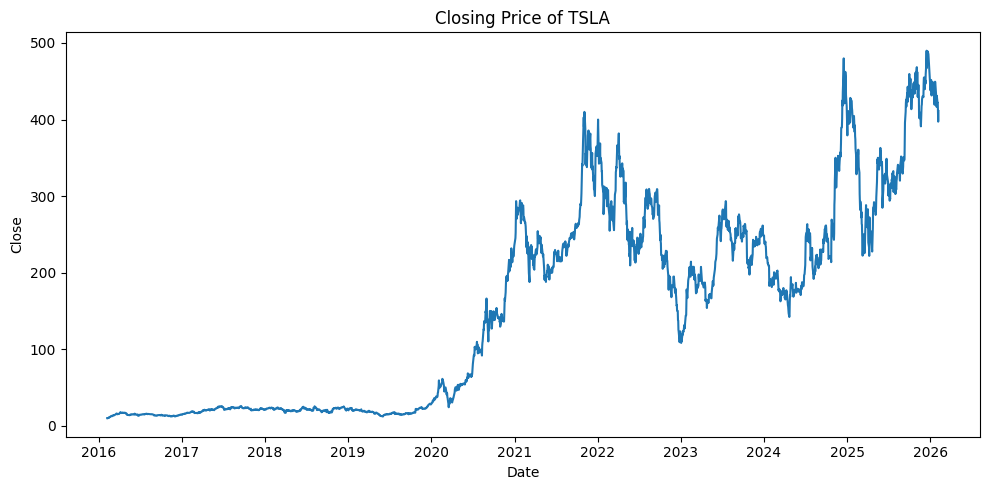

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(data_dict['TSLA']['Close'])
plt.ylabel('Close')
plt.xlabel('Date')
plt.title("Closing Price of TSLA")
plt.tight_layout()
plt.show()


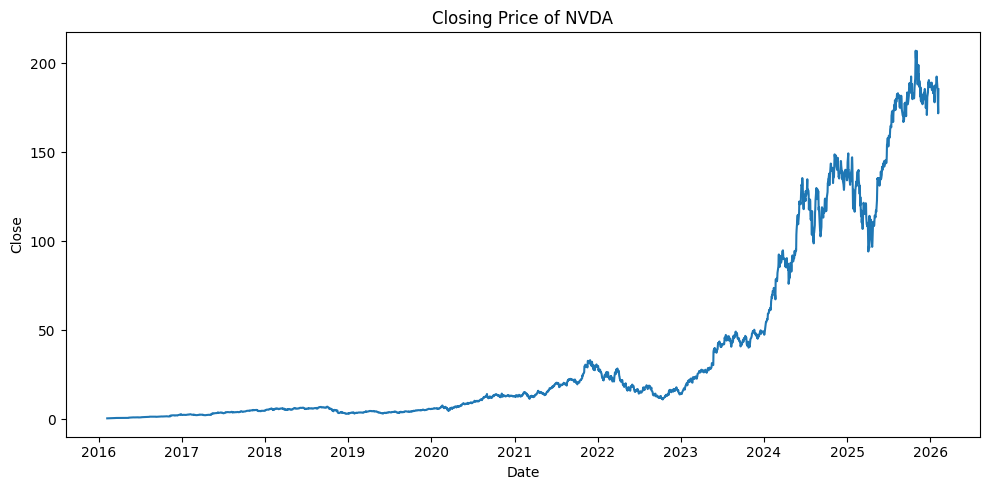

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(data_dict['NVDA']['Close'])
plt.ylabel('Close')
plt.xlabel('Date')
plt.title("Closing Price of NVDA")
plt.tight_layout()
plt.show()


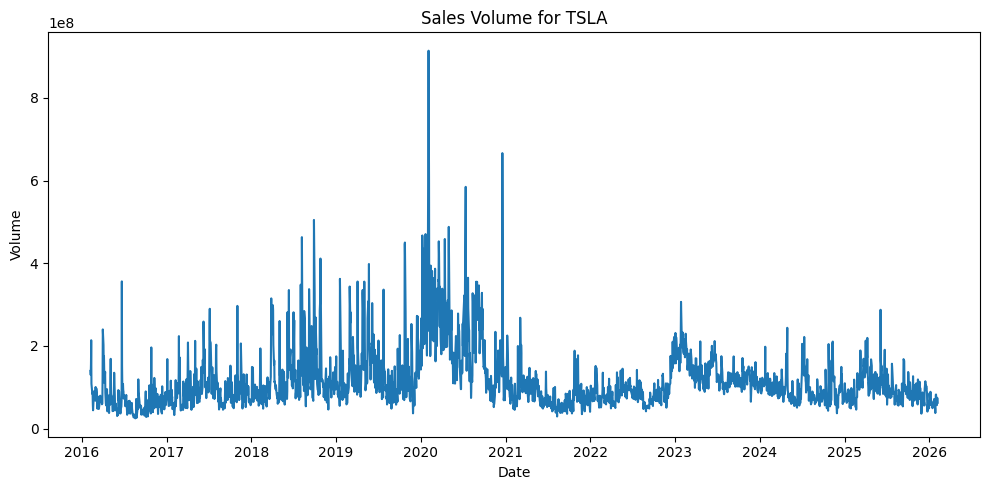

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(data_dict['TSLA']['Volume'])
plt.ylabel('Volume')
plt.xlabel('Date')
plt.title("Sales Volume for TSLA")
plt.tight_layout()
plt.show()


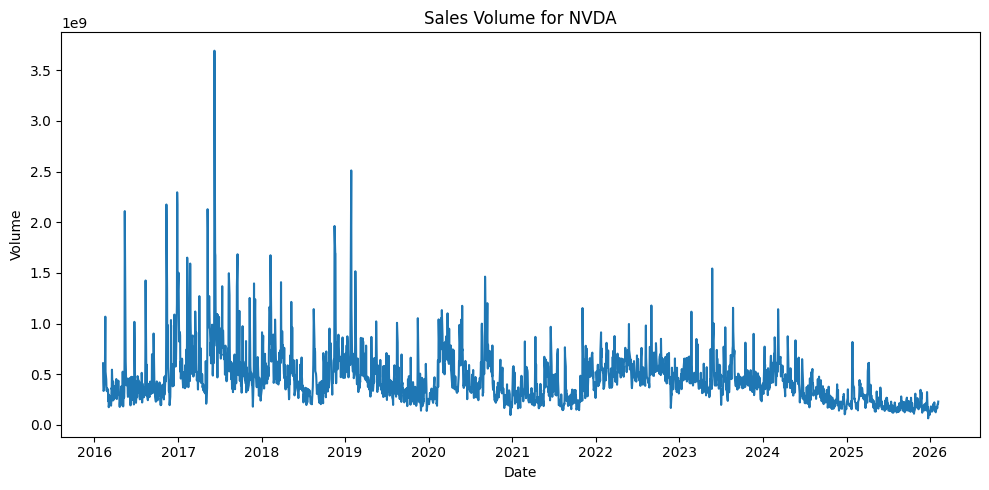

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(data_dict['NVDA']['Volume'])
plt.ylabel('Volume')
plt.xlabel('Date')
plt.title("Sales Volume for NVDA")
plt.tight_layout()
plt.show()


In [ ]:

closing_df = pd.DataFrame()
for ticker in tech_list:
    temp_df = yf.download(ticker, start=start, end=end)
    closing_df[ticker] = temp_df['Close']

tech_rets = closing_df.pct_change()
tech_rets.head()

/tmp/ipython-input-2671460246.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp_df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2671460246.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp_df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


,TSLA,NVDA
Date,,
2016-02-08,NaN,NaN
2016-02-09,0.001757,0.010706
2016-02-10,-0.030894,-0.002354
2016-02-11,0.047331,-0.005112
2016-02-12,0.003788,0.016996


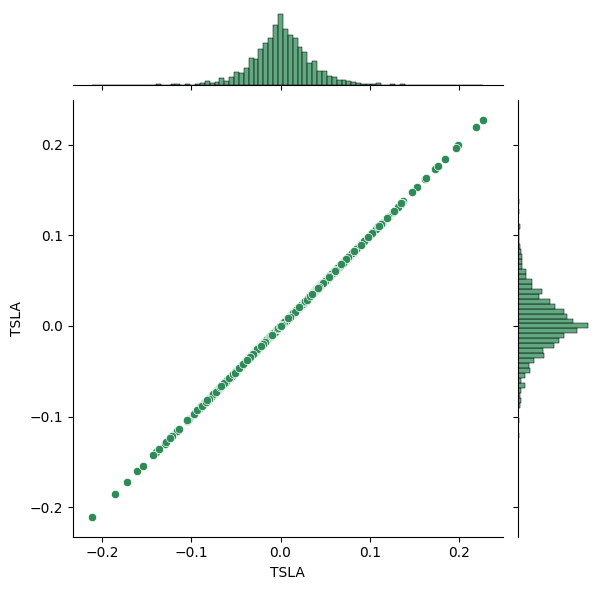

In [ ]:
sns.jointplot(x='TSLA', y='TSLA', data=tech_rets, kind='scatter', color='seagreen')

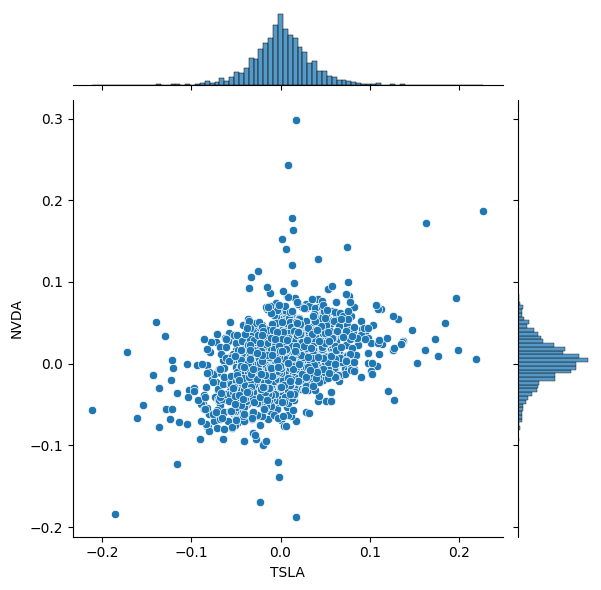

In [ ]:
sns.jointplot(x='TSLA', y='NVDA', data=tech_rets, kind='scatter')


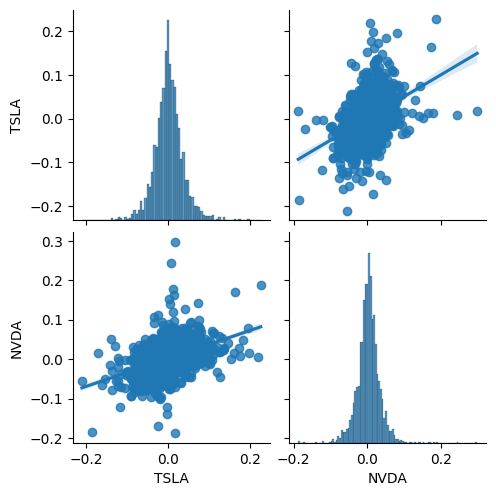

In [ ]:

sns.pairplot(tech_rets, kind='reg')

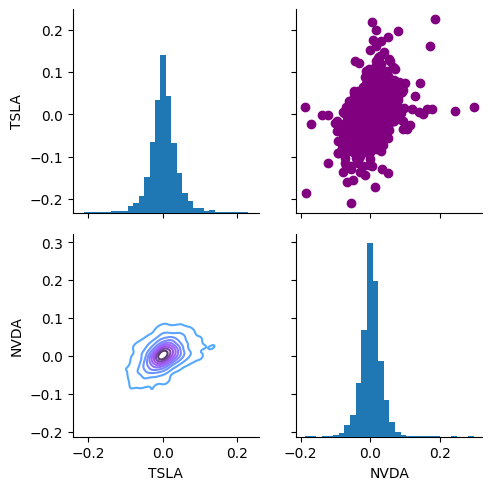

In [ ]:

return_fig = sns.PairGrid(tech_rets.dropna())

return_fig.map_upper(plt.scatter, color='purple')

return_fig.map_lower(sns.kdeplot, cmap='cool_d')

return_fig.map_diag(plt.hist, bins=30)

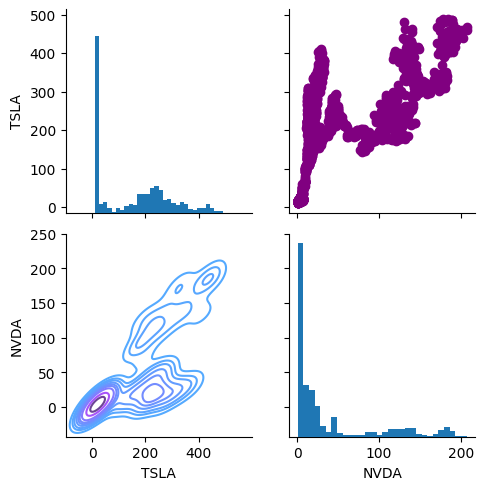

In [ ]:

returns_fig = sns.PairGrid(closing_df)

returns_fig.map_upper(plt.scatter,color='purple')

returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

returns_fig.map_diag(plt.hist,bins=30)

Text(0.5, 1.0, 'Correlation of stock closing price')

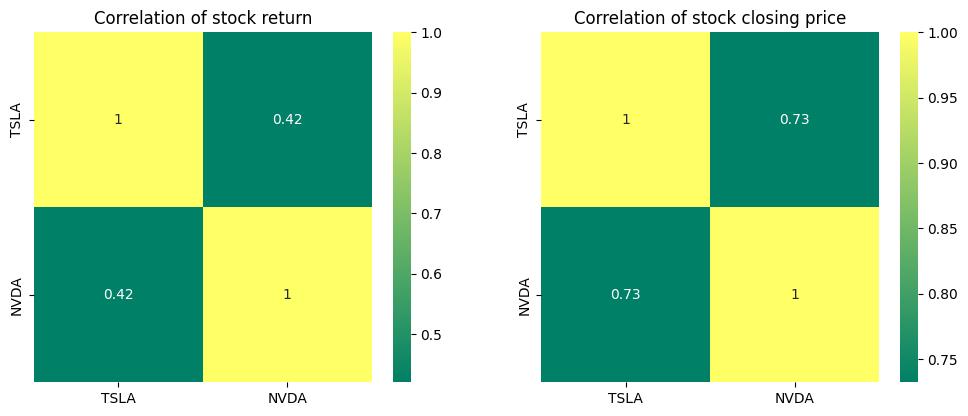

In [ ]:

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')